# Visualization Tutorial

This tutorial covers NeuRodent's comprehensive visualization capabilities for EEG analysis results.

## Overview

NeuRodent provides three main plotting classes:

1. **AnimalPlotter**: Visualize data from a single animal
2. **ExperimentPlotter**: Compare data across multiple animals with grouping
3. **ZeitgeberPlotter**: Circadian rhythm plots using Zeitgeber Time (ZT)

They support various plot types: time series, categorical plots, heatmaps, and more.

This tutorial runs on the small example recordings bundled with the package, so every
cell below executes as written after a plain `pip install neurodent`.

In [1]:
import tempfile
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from neurodent import (
    AnimalAnalyzer,
    AnimalOrganizer,
    AnimalPlotter,
    ExperimentPlotter,
    ZeitgeberAnalysisResult,
    ZeitgeberPlotter,
    constants,
    set_channel_map,
)

/home/runner/work/neurodent/neurodent/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Single Animal Visualization (AnimalPlotter)

### Setup

First declare the channel map and the per-animal metadata, then build a
`WindowAnalysisResult` from the bundled example recordings. `ANIMAL_METADATA` is what gives
each animal its genotype, which the grouped plots later in this tutorial rely on.

The two animals are given different times of day so that the day/night (`isday`) comparisons
below have both values to work with.

In [2]:
from neurodent.data import sample_dataset

SAMPLE_DATA = sample_dataset()

### Using your own data

Replace `SAMPLE_DATA` with your own directory and set `extract_func` for your format.
[Data Loading](../quickstart/data_loading.ipynb) covers readers and patterns.


In [3]:
set_channel_map({
    "LMot": ["C-015", "D-015"],
    "RMot": ["C-016", "D-016"],
    "LBar": ["C-014", "D-014"],
    "RBar": ["C-017", "D-017"],
    "LHip": ["C-012", "D-012"],
    "RHip": ["C-019", "D-019"],
    "LAud": ["C-009", "D-009"],
    "RAud": ["C-022", "D-022"],
    "LVis": ["C-010", "D-010"],
    "RVis": ["C-021", "D-021"],
})

# Per-animal genotype and sex. Every WindowAnalysisResult re-reads this at construction,
# so it is the single source of truth for animal metadata.
constants.ANIMAL_METADATA = {
    "A10": {"genotype": "WT", "sex": "Male"},
    "F22": {"genotype": "KO", "sex": "Female"},
}

DATA_PATTERN = [
    str(SAMPLE_DATA / "{animal}" / "*_ColMajor.bin"),
    str(SAMPLE_DATA / "{animal}" / "*_Meta.csv"),
]
READER = "neurodent.readers:read_bin_csv_pair"
FEATURES = ['rms', 'psdband', 'cohere', 'pcorr', 'psd']


def build_war(animal_id, recording_start):
    """Build a WindowAnalysisResult for one animal from the bundled example data."""
    ao = AnimalOrganizer(
        pattern=DATA_PATTERN,
        animal_id=animal_id,
        lro_kwargs={
            "mode": "si",
            "extract_func": READER,
            "manual_datetimes": recording_start,
        },
    )
    analyzer = AnimalAnalyzer(ao)
    analyzer.compute_bad_channels()
    return analyzer.compute_windowed_analysis(FEATURES, multiprocess_mode='serial')


# A10 is recorded during the day, F22 at night
war = build_war("A10", datetime(2023, 12, 13, 12, 0))

# Create plotter
ap = AnimalPlotter(war)

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 23.38it/s]


Processing rows:  25%|██▌       | 3/12 [00:00<00:00, 23.84it/s]

Processing rows:  50%|█████     | 6/12 [00:00<00:00, 23.45it/s]

Processing rows:  75%|███████▌  | 9/12 [00:00<00:00, 23.46it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 23.35it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 23.38it/s]

### Time Series Plots

Visualize features over time. `AnimalPlotter` methods draw and display the figure
themselves. They do not return a `Figure` object, so there is nothing to assign and no need to call
`plt.show()` afterwards. One figure is produced per recording session.

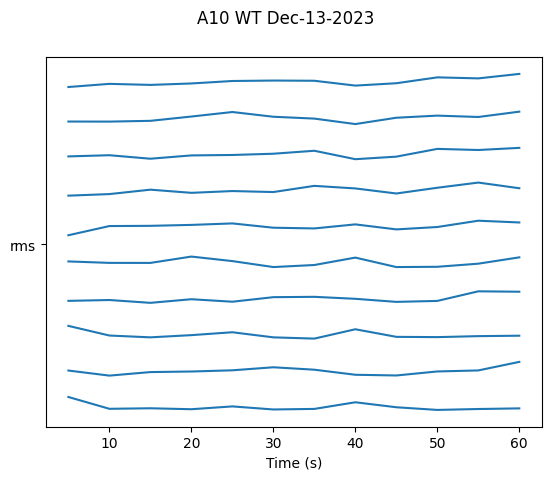

In [4]:
# Plot RMS amplitude over time, one trace per channel
ap.plot_linear_temporal(features=['rms'])

### Band Power Visualization

`psdband` holds one value per frequency band per channel, so `plot_linear_temporal` draws it
as a set of band traces. `plot_psd_histogram` is a different view of the spectrum: it plots
the full `psd` feature on log-log axes and fits a slope to each channel.

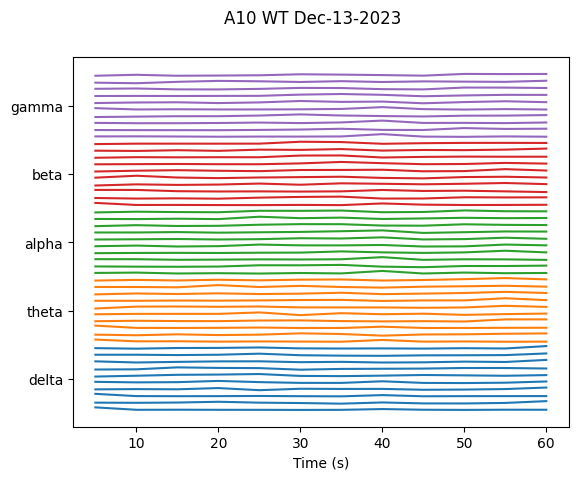

/home/runner/work/neurodent/neurodent/src/neurodent/plotting/animal.py:612: RuntimeWarning: divide by zero encountered in log10
  freqs, 10 ** (b + m * np.log10(freqs)), c=f"C{j}", alpha=0.75


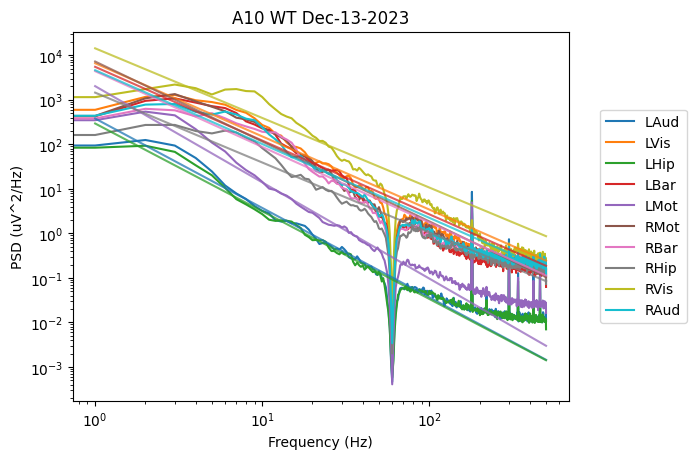

In [5]:
# Band powers over time
ap.plot_linear_temporal(features=['psdband'])

# Power spectrum with a fitted slope per channel
ap.plot_psd_histogram()

## 2. Multi-Animal Comparison (ExperimentPlotter)

### Setup

In [6]:
# Build a second animal so there are two genotypes to compare
war_f22 = build_war("F22", datetime(2023, 12, 12, 2, 0))
wars = [war, war_f22]

# Create experiment plotter.
# Pass the same feature list used to compute the WARs -- `features` defaults to "all",
# which would then fail on every feature that was not computed.
EXCLUDE = ['nspike', 'lognspike']
ep = ExperimentPlotter(
    wars,
    features=FEATURES,
    exclude=EXCLUDE,
)

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 23.25it/s]


Processing rows:  25%|██▌       | 3/12 [00:00<00:00, 23.74it/s]

Processing rows:  50%|█████     | 6/12 [00:00<00:00, 23.68it/s]

Processing rows:  75%|███████▌  | 9/12 [00:00<00:00, 23.47it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 23.10it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 23.25it/s]

### Categorical Plots

Compare features across groups using box plots, violin plots, swarm plots, etc.

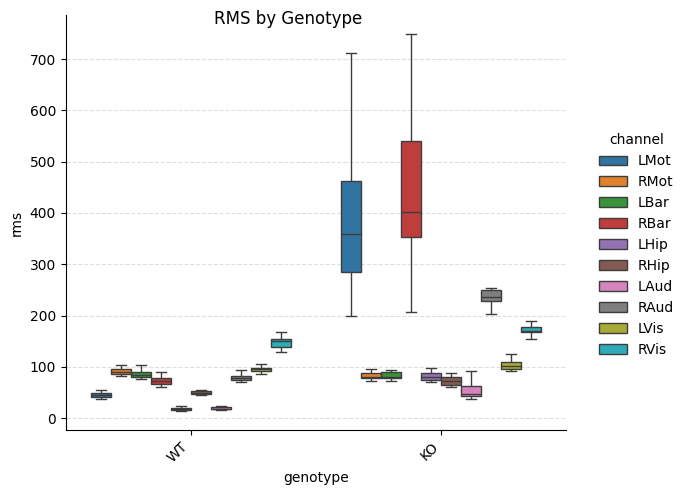

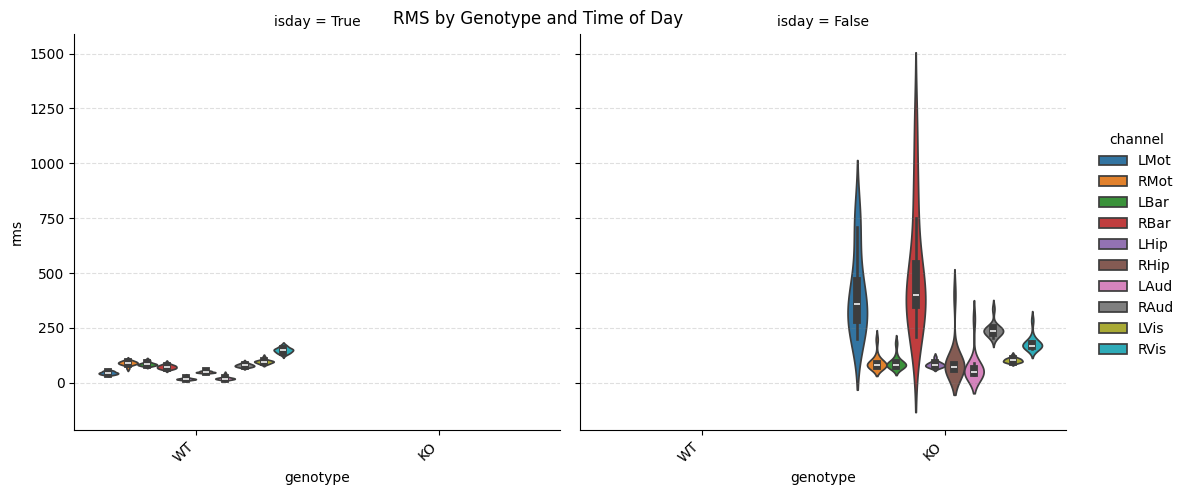

In [7]:
# Box plot grouped by genotype
ep.plot_catplot(
    'rms',
    groupby='genotype',
    kind='box',
    catplot_params={'showfliers': False}
)
plt.suptitle("RMS by Genotype")
plt.show()

# Violin plot with day/night comparison
ep.plot_catplot(
    'rms',
    groupby=['genotype', 'isday'],
    x='genotype',
    col='isday',
    kind='violin'
)
plt.suptitle("RMS by Genotype and Time of Day")
plt.show()

### Band Power Comparisons

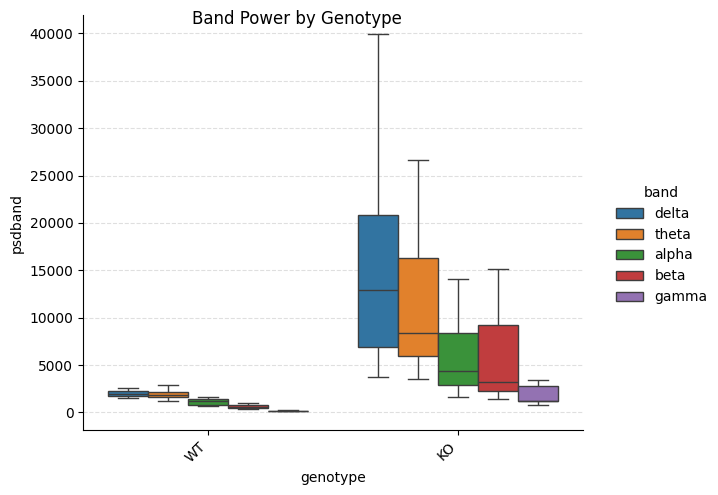

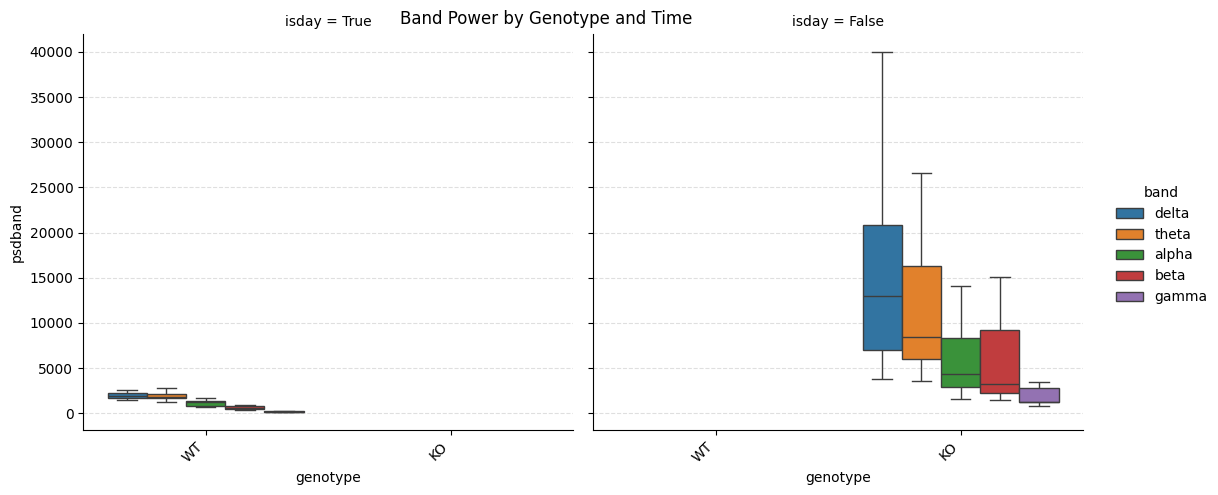

In [8]:
# Box plot of band powers by genotype
ep.plot_catplot(
    'psdband',
    groupby='genotype',
    x='genotype',
    hue='band',
    kind='box',
    collapse_channels=True,
    catplot_params={'showfliers': False}
)
plt.suptitle("Band Power by Genotype")
plt.show()

# With day/night split
ep.plot_catplot(
    'psdband',
    groupby=['genotype', 'isday'],
    x='genotype',
    col='isday',
    hue='band',
    kind='box',
    collapse_channels=True,
    catplot_params={'showfliers': False}
)
plt.suptitle("Band Power by Genotype and Time")
plt.show()

### Swarm and Point Plots

Show individual data points with averages:

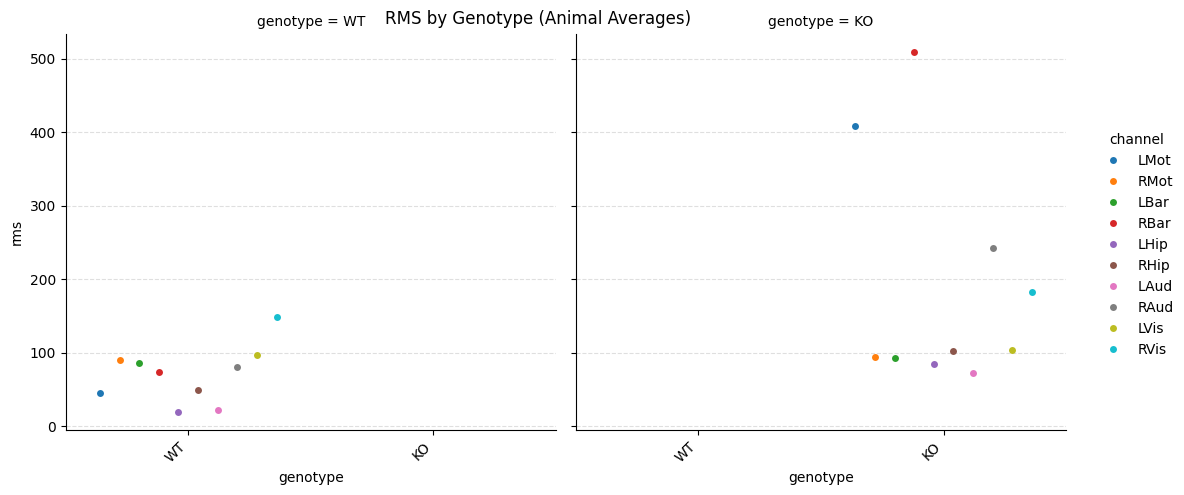

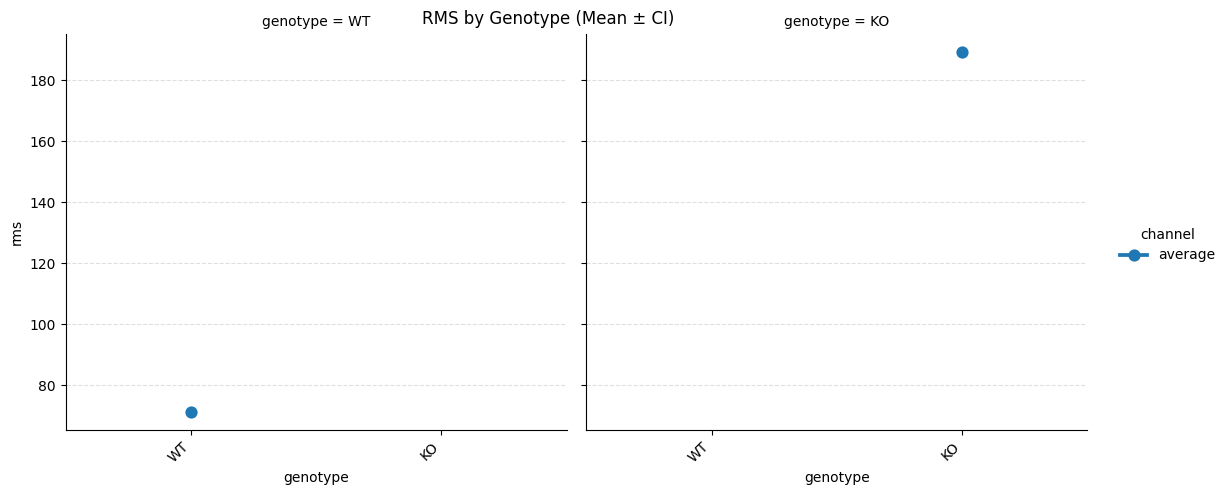

In [9]:
# Swarm plot with animal-level averaging
ep.plot_catplot(
    'rms',
    groupby=['animal', 'genotype'],
    x='genotype',
    hue='channel',
    kind='swarm',
    average_groupby=True,
    collapse_channels=False,
    catplot_params={'dodge': True, 'errorbar': 'ci'}
)
plt.suptitle("RMS by Genotype (Animal Averages)")
plt.show()

# Point plot with confidence intervals
ep.plot_catplot(
    'rms',
    groupby=['animal', 'genotype'],
    x='genotype',
    kind='point',
    average_groupby=True,
    collapse_channels=True,
    catplot_params={'errorbar': 'ci'}
)
plt.suptitle("RMS by Genotype (Mean ± CI)")
plt.show()

## 3. Connectivity Visualization

### Heatmaps for Coherence and Correlation

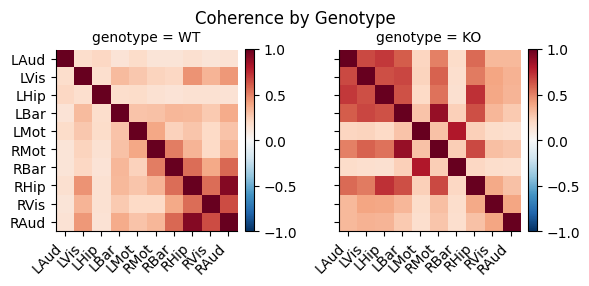

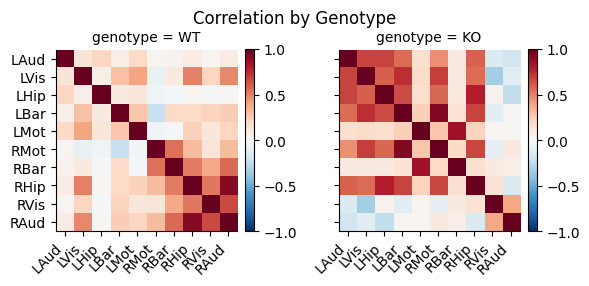

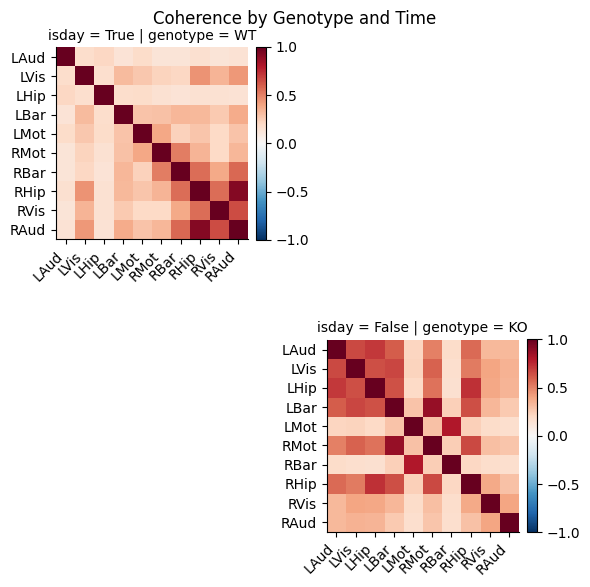

In [10]:
# Coherence heatmap by genotype
ep.plot_heatmap(
    'cohere',
    groupby='genotype'
)
plt.suptitle("Coherence by Genotype")
plt.show()

# Pearson correlation heatmap
ep.plot_heatmap(
    'pcorr',
    groupby='genotype'
)
plt.suptitle("Correlation by Genotype")
plt.show()

# With day/night comparison
ep.plot_heatmap(
    'cohere',
    groupby=['genotype', 'isday']
)
plt.suptitle("Coherence by Genotype and Time")
plt.show()

### Difference Heatmaps

Show differences relative to a baseline condition:

/home/runner/work/neurodent/neurodent/src/neurodent/plotting/experiment.py:1116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_base = df.groupby(baseline_groupby, as_index=False).get_group(
/home/runner/work/neurodent/neurodent/src/neurodent/plotting/experiment.py:1127: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baseline_means = df_base.groupby(remaining_groupby)[feature].apply(


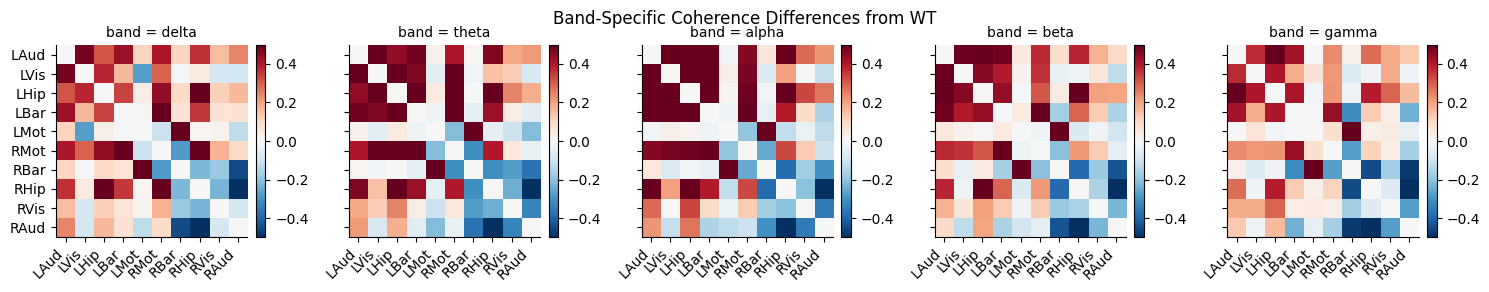

In [11]:
# Difference from wildtype, broken out by frequency band.
# `baseline_groupby` names the column holding the baseline label, and `remove_baseline`
# drops the baseline group itself from the output.
ep.plot_diffheatmap(
    'cohere',
    groupby='genotype',
    baseline_key='WT',
    baseline_groupby='genotype',
    col='band',
    remove_baseline=True
)
plt.suptitle("Band-Specific Coherence Differences from WT")
plt.show()

## 4. QQ Plots for Distribution Analysis

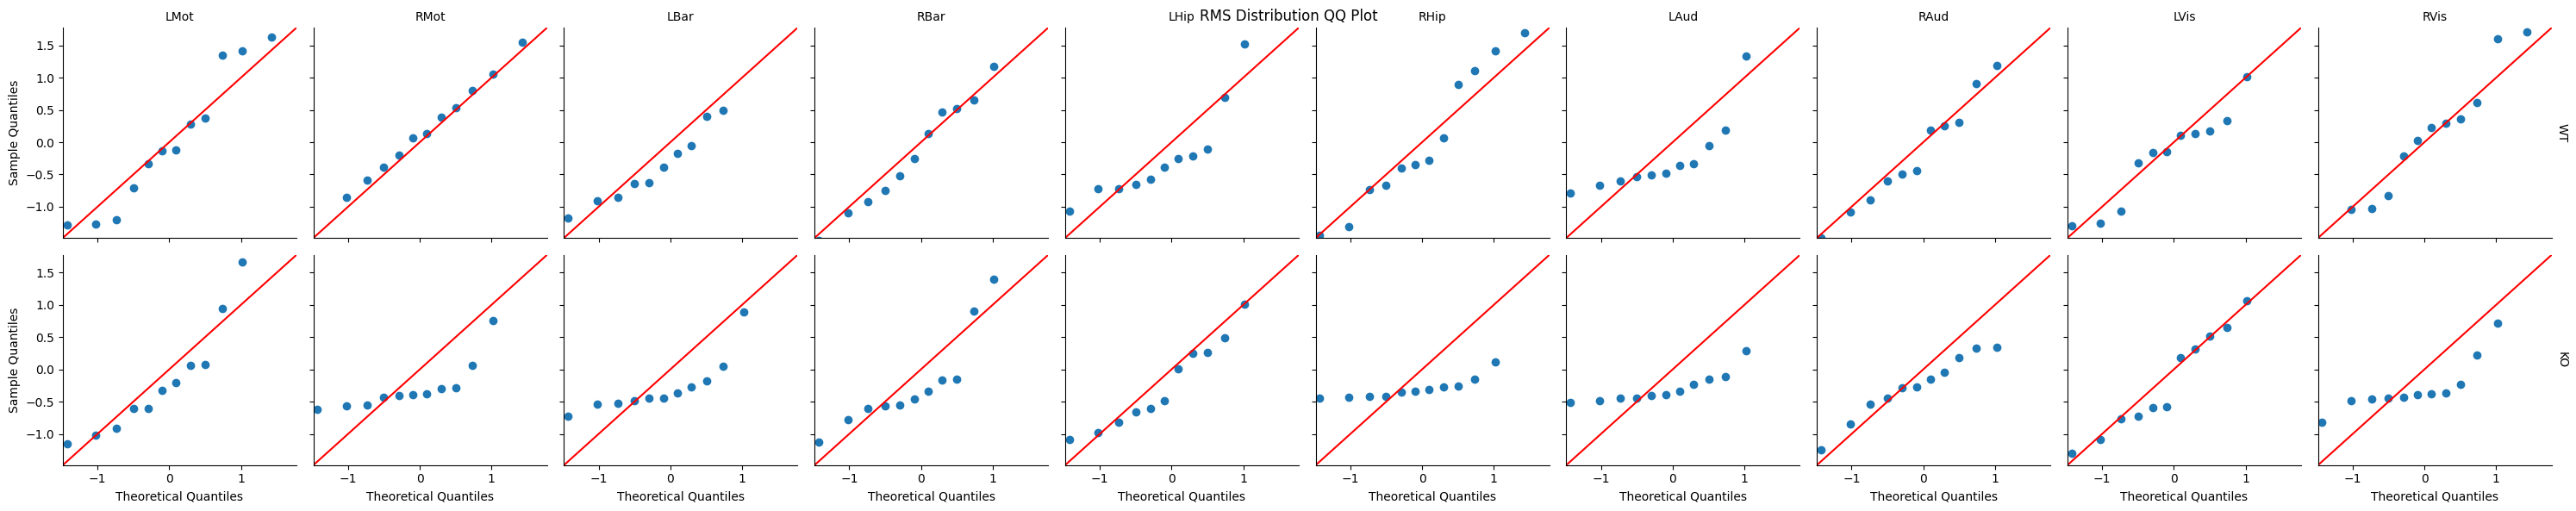

In [12]:
# QQ plot by genotype and channel
ep.plot_qqplot(
    'rms',
    groupby=['genotype'],
    row='genotype',
    col='channel',
    height=3
)
plt.suptitle("RMS Distribution QQ Plot")
plt.show()

## 5. Customizing Plots

### Plot Parameters

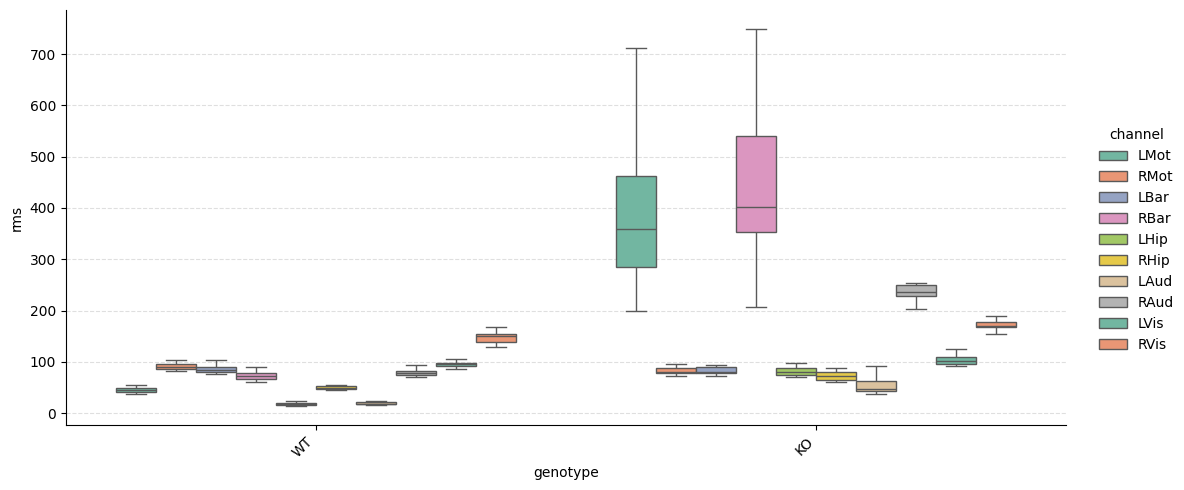

In [13]:
# Custom catplot parameters
custom_params = {
    'showfliers': False,
    'aspect': 2,
    'height': 5,
    'palette': 'Set2'
}

ep.plot_catplot(
    'rms',
    groupby='genotype',
    kind='box',
    catplot_params=custom_params
)
plt.show()

### Channel Collapsing

Average across channels:

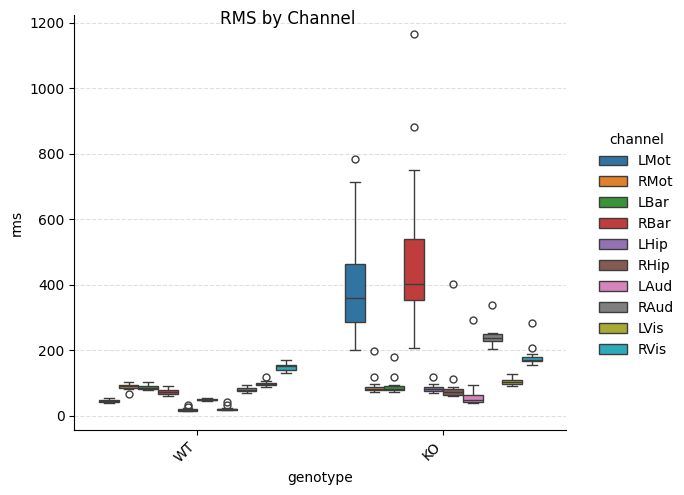

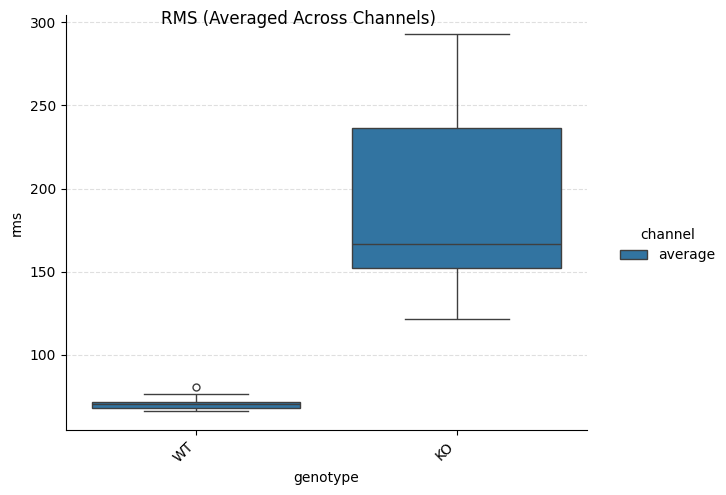

In [14]:
# Without channel collapsing (show all channels)
ep.plot_catplot(
    'rms',
    groupby='genotype',
    kind='box',
    collapse_channels=False
)
plt.suptitle("RMS by Channel")
plt.show()

# With channel collapsing (average across channels)
ep.plot_catplot(
    'rms',
    groupby='genotype',
    kind='box',
    collapse_channels=True
)
plt.suptitle("RMS (Averaged Across Channels)")
plt.show()

## 6. Saving Figures

Save high-quality figures for publications:

Figures saved to /tmp/tmplfucwwkn


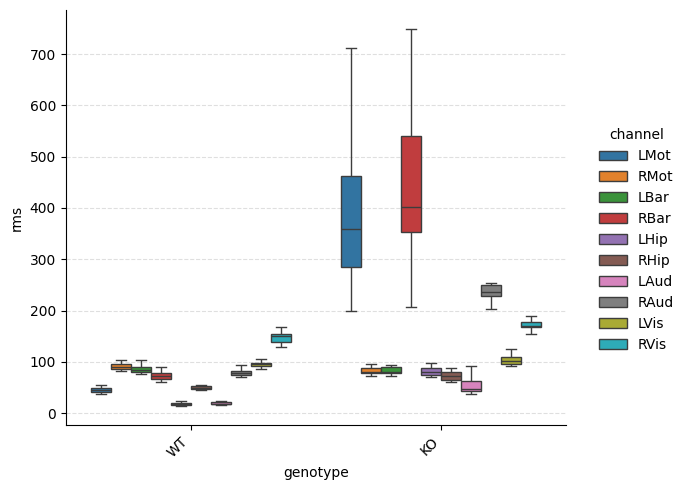

In [15]:
# Use a temporary directory so this tutorial does not write into the docs source tree.
# In your own work this would be a real output folder.
output_folder = Path(tempfile.mkdtemp())

# Generate and save plot
g = ep.plot_catplot(
    'rms',
    groupby='genotype',
    kind='box',
    catplot_params={'showfliers': False}
)

# Save as PNG (high DPI for publications)
g.savefig(output_folder / 'rms_by_genotype.png', dpi=300, bbox_inches='tight')

# Save as PDF (vector format)
g.savefig(output_folder / 'rms_by_genotype.pdf', bbox_inches='tight')

print(f"Figures saved to {output_folder}")

## 7. Batch Figure Generation

Generate multiple figures systematically:

In [16]:
# Generate plots for all linear features that were computed.
# `ExperimentPlotter` does not keep the exclude list, so reuse the one declared above.
for feature in constants.LINEAR_FEATURES:
    if feature in EXCLUDE or feature not in FEATURES:
        continue

    print(f"Generating plot for {feature}")

    # Box plot
    g = ep.plot_catplot(
        feature,
        groupby='genotype',
        kind='box',
        collapse_channels=True,
        catplot_params={'showfliers': False}
    )
    g.savefig(
        output_folder / f'{feature}_genotype_box.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()

print("Batch generation complete!")

Generating plot for rms
Batch generation complete!


Batch generation complete!


## 8. Advanced: Custom Plot Types

Access underlying data for custom visualizations:

['genotype', 'channel', 'rms']


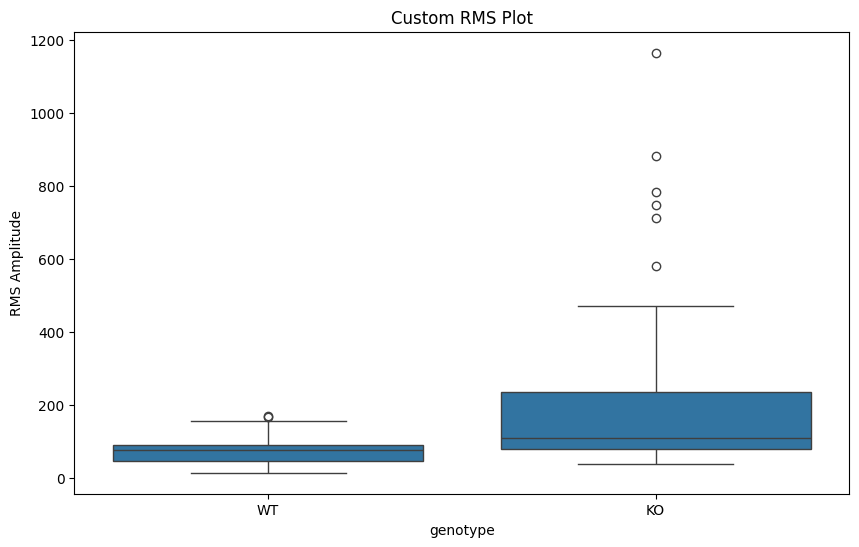

In [17]:
# Get the long-form dataframe backing the plots.
# Columns are the groupby keys, plus 'channel' and one column named after the feature.
df = ep.pull_timeseries_dataframe('rms', groupby='genotype')
print(df.columns.tolist())

# Create custom plot with matplotlib
fig, ax = plt.subplots(figsize=(10, 6))

# Plot using pandas/seaborn directly
sns.boxplot(data=df, x='genotype', y='rms', ax=ax)
ax.set_title("Custom RMS Plot")
ax.set_ylabel("RMS Amplitude")
plt.show()

## 9. Circadian Rhythms (ZeitgeberPlotter)

Visualize circadian patterns using `ZeitgeberPlotter`. This specialized plotter handles the
48-hour duplicated time axis often used in circadian research.

`ZeitgeberPlotter` needs one scalar per row, so feed it
`ZeitgeberAnalysisResult.get_channel_averaged_result()` rather than `get_result()`. The
latter keeps one array of per-channel values in each feature cell. Channel-averaging is also
what produces the baseline-subtracted `*_nobase` columns, since baseline subtraction only
applies to numeric columns.

The bundled excerpts are 60 seconds long, so every window falls in the same Zeitgeber bin.
The curve below therefore demonstrates the plot's shape and axis handling rather than a real
circadian profile.

In [18]:
# Wrap a WAR in the Zeitgeber pipeline and average across channels
zar = ZeitgeberAnalysisResult(war)
df_zar = zar.get_channel_averaged_result(features=['rms'])

print("ZT columns:", [c for c in df_zar.columns if c.startswith('zt') or '_nobase' in c])

zp = ZeitgeberPlotter(df_zar)

# Plot a single feature against Zeitgeber time
zp.plot_feature(
    'rms_nobase',    # Baseline-subtracted feature
    output_path=output_folder / 'circadian_rms.png',
    figsize=(10, 6)
)
print(f"Circadian plot written to {output_folder / 'circadian_rms.png'}")

ZT columns: ['zt_minutes', 'duration_nobase', 'rms_nobase']
Circadian plot written to /tmp/tmplfucwwkn/circadian_rms.png


Circadian plot written to /tmp/tmplfucwwkn/circadian_rms.png


## Next Steps

- **[Windowed Analysis Tutorial](windowed_analysis.ipynb)**: Generate data for visualization
- **[Basic Usage Tutorial](../quickstart/basic_usage.ipynb)**: Complete workflow